# **Projektowanie Leków -- Uczenie Maszynowe**

## Przygotowanie i importowanie pakietów

Wykonaj poniższe komórki, żeby zainstalować i zaimportować wszystkie potrzebne pakiety

In [1]:
!pip install -q rdkit
!pip install -q torch_geometric
!pip -qqq install torcheval torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.6/36.6 MB 28.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 38.6 MB/s eta 0:00:00


In [2]:
import os
import torch
import random
import logging
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torcheval.metrics import BinaryAccuracy
from torch_geometric.nn import GINEConv, global_add_pool
from torchmetrics.classification import BinaryConfusionMatrix

from rdkit import Chem
from rdkit import RDLogger
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, precision_score, recall_score


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)


cuda


### **Zadanie 3.1**

Załaduj przygotowane wcześniej dane (w pliku csv) do obiektu klasy `DataFrame` o nazwie `data`

In [4]:
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)


In [5]:
if not os.path.exists('cyp1a2.tab'):
    print('Download cyp1a2.tab.')
    !wget -q https://raw.githubusercontent.com/kugi8412/DockGraph/CYP1A2/SelectGINE/CYP1A2/data/cyp1a2.tab -O cyp1a2.tab

if not os.path.exists('prepare_data.csv'):
    print('Download prepare_data.csv.')
    !wget -q https://raw.githubusercontent.com/kugi8412/DockGraph/CYP1A2/SelectGINE/CYP1A2/data/prepare_data.csv -O prepare_data.csv


Download cyp1a2.tab.
Download prepare_data.csv.


### **Zadanie 3.2**

Podziel `data` na `inputs` (porządane `features` do treningu)  i `labels`

In [6]:
data = pd.read_csv('prepare_data.csv')

inputs = data.drop(columns=['label'])
labels = data['label']

X = inputs.values.astype(np.float32)
y = labels.values.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)


### **Zadanie** 3.3 (Train-test split)

Podziel dane na zbiory treningowy, walidacyjny i testowy (np 70% danych treningowych, 15% walidacyjnych i 15% testowych).

Możesz wykorzystać:
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

Przygotuj dane w formacie obiektów `torch.Tensor`; osobno inputów i outputów, np. `test_inputs` i `test_labels`. Dla splitu 75%,15%,15% i danych przygotownych wg. instrukcji z 1. części ćwiczenia obiekt `test_inputs` powinien mieć wymiary `(1886,9)` (może być więcej, jeśli masz więcej *features*, a `test_labels` wymiar `(1886,1)`

In [7]:
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train).unsqueeze(1)

X_val_tensor = torch.tensor(X_val)
y_val_tensor = torch.tensor(y_val).unsqueeze(1)

X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test).unsqueeze(1)


## **Zadanie 4:** Budujemy i trenujemy sieć neuronową

### **Zadanie 4.1:**

Zdefiniuj model sieci. Użyj funkcji `torch.nn.Sequential()` oraz zwykłych warstw gęsto połączonych `torch.nn.Linear()` i funkcji aktywacji `ReLU`.

**Dokumentacja PyTorch:**

https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html
https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html

In [8]:
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(32, 1)
)

### **Zadanie 4.2** Funkcja strat i minimalizacja

**Zdefiniuj funkcję strat `loss_fn` oraz optymalizator `optimizer`.**

Jako funkcję strat polecamy `Binary Crossentropy`. Należy jednak zwrócić uwagę na to jaki mamy output z sieci. Jeżeli na końcu mamy zwykłą warstwę "gęstą" (innymi słowy liniową funkcję aktywacji), to outputy są na skali $(-\infty; +\infty)$ i musimy zaznaczyć, że funkcja jest "from logits". Jeżeli natomiast mamy na końcu funkcję `Sigmoid`, to wyjście jest odpowiednikiem prawdopodobieństwa (w skali $[0;1]$) i nie należy dodawać "from logits". W praktyce różnica jest taka, że jeśli użyjemy funkcji strat w wariancie "from logits"), to jedyna różnica jest taka, że na jej początku output z sieci jest przepuszczony przez Sigmoid.

https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html
https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html

Są różne możliwe algorytmy minimalizujące funkcję strat, które powinny dążyć do tego samego. Różnią się one natomiast szybkością i skutecznością. Można też im ustawiać różne parametry, takie jak `learning_rate`, które określa jak szybko powinniśmy zbiegać do minimum. Zbyt małe learning rate może powodować bardzo wolny trening, a zbyt wysokie może prowadzić do przeskakiwania maksimum i niepowodzenie w treningu. Można też w pętli treningowej zmieniać learning_rate w zależności od potrzeb. Polecamy skorzystać z optymalizatora `Adam` z domyślnymi parametrami i modyfikować parametry w miarę potrzeb.
https://pytorch.org/docs/stable/generated/torch.optim.Adam.html

In [9]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=9e-4)


### **Zadanie 4.3** Prosta pętla treningowa

**Wytrenuj zdefiniowany wcześniej model**. Oznacza to wykonanie w pętli kilku kluczowych kroków:
- `outputs = model(train_inputs)` - *forward pass* - obliczenie danych wyjściowych dla danych treningowych
- `loss = loss_fn(outputs, train_labels)` - obliczenie wartości funkcji strat
- `loss.backward()` - *backpropagation* - obliczenie gradientów
- `optimizer.step()` aktualizacja wag na podstawie tychże gradientów
- `optimizer.zero_grad()` - wyzerowanie gradientów na potrzeby kolejnej iteracji

Zapisuj również wartości funkcji strat w każdym kroku. Śledzenie ich pozwala ocenić progres treningu. Wartość tę w danej chwili można uzsyskać wywołując `loss.item()`. Powinieneś śledzić wartość funkcji strat również dla zbioru walidacyjnego; pozwoli to ocenić czy model nie jest przetrenowany.

Jeśli chcesz zresetować parametry modelu, żeby wytrenować go jeszcze raz (od zera), możesz to zrobić wykonując
```python
for layer in model.children():
  if hasattr(layer, 'reset_parameters'):
    layer.reset_parameters()
```



In [10]:
num_epochs = 100
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()

    # Forward
    outputs = model(X_train_tensor)
    loss = loss_fn(outputs, y_train_tensor)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    model.eval()

    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = loss_fn(val_outputs, y_val_tensor)
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}')

        val_losses.append(val_loss.item())


Epoch 5/100 | Train Loss: 0.6674 | Val Loss: 0.6371
Epoch 10/100 | Train Loss: 0.6168 | Val Loss: 0.5775
Epoch 15/100 | Train Loss: 0.5752 | Val Loss: 0.5327
Epoch 20/100 | Train Loss: 0.5633 | Val Loss: 0.5219
Epoch 25/100 | Train Loss: 0.5442 | Val Loss: 0.5189
Epoch 30/100 | Train Loss: 0.5361 | Val Loss: 0.5157
Epoch 35/100 | Train Loss: 0.5313 | Val Loss: 0.5046
Epoch 40/100 | Train Loss: 0.5234 | Val Loss: 0.4977
Epoch 45/100 | Train Loss: 0.5156 | Val Loss: 0.4910
Epoch 50/100 | Train Loss: 0.5122 | Val Loss: 0.4829
Epoch 55/100 | Train Loss: 0.4995 | Val Loss: 0.4764
Epoch 60/100 | Train Loss: 0.4962 | Val Loss: 0.4691
Epoch 65/100 | Train Loss: 0.4920 | Val Loss: 0.4645
Epoch 70/100 | Train Loss: 0.4871 | Val Loss: 0.4601
Epoch 75/100 | Train Loss: 0.4784 | Val Loss: 0.4556
Epoch 80/100 | Train Loss: 0.4777 | Val Loss: 0.4519
Epoch 85/100 | Train Loss: 0.4789 | Val Loss: 0.4485
Epoch 90/100 | Train Loss: 0.4717 | Val Loss: 0.4469
Epoch 95/100 | Train Loss: 0.4666 | Val Loss: 0

### **Zadanie 4.4**

Wykonaj wykres wartości funkcji strat dla zbioru treningowego i walidacyjnego dla kolejnych epok. Obie funkcje powinny maleć podczas treningu. Jeżeli straty na zbiorze treningowym maleją podczas gdy te na zbiorze walidacyjnym pozostają stałe, bądź rosną, najprawdopodobniej sieć jest już przetrenowana!

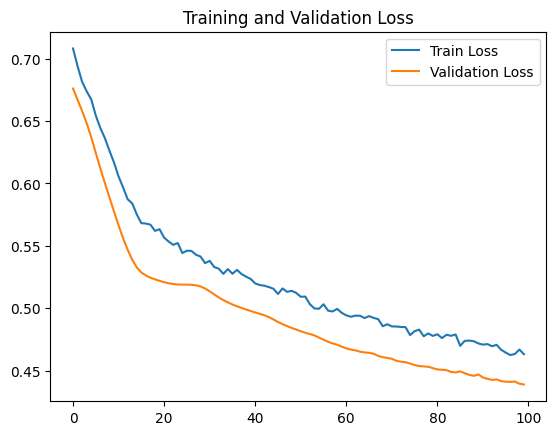

In [11]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


## **Zadanie 5:** Testowanie wytrenowanej sieci

### **Zadanie 5.1**

Wykorzystaj wytrenowaną sieć, żeby wykonać predykcje dla zbioru testowego. Zapisz wyniki również w formacie binarnym (np. [0,1,0,...,0]), żeby móc je łatwo porównać z prawdziwymi etykietami

In [12]:
# ROZWIAZANIE
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_probs = torch.sigmoid(test_outputs)
    preds = (test_probs > 0.5).float()


### **Zadanie 5.2**

Wyznacz tablicę pomyłek (confusion matrix). Możesz do tego użyć funkcji z `PyTorch` (link poniżej)

https://en.wikipedia.org/wiki/Confusion_matrix

https://lightning.ai/docs/torchmetrics/stable/classification/confusion_matrix.html

In [13]:
y_true = y_test_tensor.numpy()
y_pred = preds.numpy()

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print('Confusion Matrix:')
print(cm)


Confusion Matrix:
[[822 191]
 [186 688]]


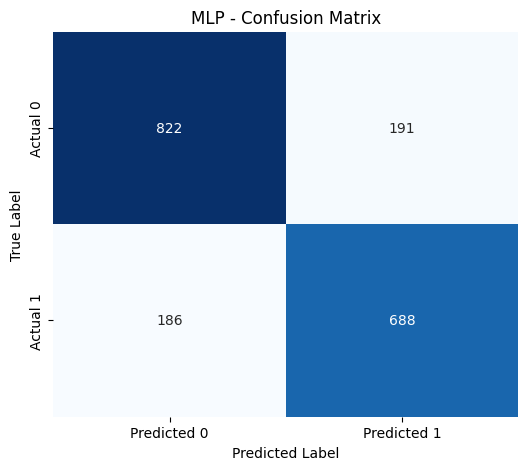

In [14]:
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap='Blues'):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
                xticklabels=[f'Predicted {classes[0]}', f'Predicted {classes[1]}'],
                yticklabels=[f'Actual {classes[0]}', f'Actual {classes[1]}'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()


plot_confusion_matrix(cm, classes=['0', '1'], title='MLP - Confusion Matrix')


Confusion matrix
- 0,0 : True negatives
- 0,1 : False positives
- 1,0 : False negatives
- 1,1 : True positives

### **Zadanie 5.3**

Wyznacz liczbę predykcji prawdziwie pozytywnych, prawdziwie negatywnych, fałszywie pozytywnych i fałszywie negatywnych (true positive, true negative, false positiv & false negative)

In [15]:
# ROZWIAZANIE
print(f'TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}')


TN: 822, FP: 191, FN: 186, TP: 688


### **Zadanie 5.4**

Wyznacz i wypisz następujące metryki opisujące skuteczność klasyfikatora binarnego:
- dokładność (accuracy)
- precyznja (precision)
- czułość (sensitivity)
- swoistość (specificity)

In [16]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
sensitivity = recall_score(y_true, y_pred)
specificity = tn / (tn + fp)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')


Accuracy: 0.8002
Precision: 0.7827
Sensitivity: 0.7872
Specificity: 0.8115


## **Zadanie 6: Modyfikacja sieci**

Wypróbuj różne liczby warstw i neuronów w poszczególnych warstwach. Spróbuj od nowa zdefiniować model i wytrenować sieć, albo użyć innych funkcji strat, bądź funkcji optymalizujących. Zobacz jak wpływają one na wygląd krzywych z zadań 4.5 i 4.6. Sprawdź jaka jest skuteczność predykcji na zbiorze testowym.

In [17]:
# Config
CONFIG = {
    'batch_size': 64,
    'epochs': 50,
    'learning_rate': 0.0005,
    'hidden_dim': 128,
    'dropout': 0.3,
    'seed': 42,
    'val_split': 0.15,
    'test_split': 0.15
}


In [18]:
# Seed
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

PERMITTED_ATOMS = ['C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'I', 'B', 'H']


# One hot
def one_hot_encoding(value, choices):
    encoding = [0] * (len(choices) + 1)
    index = choices.index(value) if value in choices else -1
    encoding[index] = 1
    return encoding


def get_atom_features(atom):
    features = one_hot_encoding(atom.GetSymbol(), PERMITTED_ATOMS)
    features += one_hot_encoding(atom.GetDegree(), [0, 1, 2, 3, 4])
    features += one_hot_encoding(atom.GetTotalNumHs(), [0, 1, 2, 3, 4])
    features += one_hot_encoding(atom.GetFormalCharge(), [-1, -2, 1, 2, 0])
    features += one_hot_encoding(str(atom.GetHybridization()), ['SP', 'SP2', 'SP3', 'SP3D', 'SP3D2'])
    features += [1 if atom.GetIsAromatic() else 0]
    features += [atom.GetMass() * 0.01]
    return features


def get_bond_features(bond):
    bt = bond.GetBondType()
    features = [
        1 if bt == Chem.rdchem.BondType.SINGLE else 0,
        1 if bt == Chem.rdchem.BondType.DOUBLE else 0,
        1 if bt == Chem.rdchem.BondType.TRIPLE else 0,
        1 if bt == Chem.rdchem.BondType.AROMATIC else 0,
    ]
    features += [1 if bond.GetIsConjugated() else 0]
    features += [1 if bond.IsInRing() else 0]
    return features


def smiles_to_graph_gine(smiles, label=None):
    """ Conversion of SMILES to Data PyTorch Geometric."""
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return None

    # Atoms features
    atom_feats = [get_atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_feats, dtype=torch.float)

    # Edges features
    rows, cols, edge_feats = [], [], []
    for bond in mol.GetBonds():
        start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        b_feat = get_bond_features(bond)
        rows += [start, end]; cols += [end, start]
        edge_feats += [b_feat, b_feat]

    if not rows:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, len(get_bond_features(Chem.MolFromSmiles("CC").GetBondWithIdx(0)))), dtype=torch.float)
    else:
        edge_index = torch.tensor([rows, cols], dtype=torch.long)
        edge_attr = torch.tensor(edge_feats, dtype=torch.float)

    y = torch.tensor([label], dtype=torch.float) if label is not None else None

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, smiles=smiles)


# GINE Classification
class GINEClassifier(nn.Module):
    def __init__(self, node_in, edge_in, hidden_dim, dropout=0.3):
        super(GINEClassifier, self).__init__()

        self.node_lin = nn.Linear(node_in, hidden_dim)
        self.edge_lin = nn.Linear(edge_in, hidden_dim)

        # GINEConv
        def make_gine_mlp():
            return nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )

        self.conv1 = GINEConv(make_gine_mlp())
        self.conv2 = GINEConv(make_gine_mlp())
        self.conv3 = GINEConv(make_gine_mlp())
        self.dropout = dropout
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = self.node_lin(x)

        if edge_attr.numel() > 0:
            edge_attr = self.edge_lin(edge_attr)
        else:
            edge_attr = torch.zeros((edge_index.size(1), x.size(1)), device=x.device)

        # Graph layers
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index, edge_attr)
        x = F.relu(x)

        # Global Pooling
        x = global_add_pool(x, batch)

        # MLP
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


In [19]:
# Input
df = pd.read_csv('cyp1a2.tab', sep='\t')
print(df.head(2))

# To graph
graphs = []
print('\nSMILES -> Graphs.')
dummy_mol = None
for idx, row in df.iterrows():
    g = smiles_to_graph_gine(row['Drug'], label=row['Y'])
    if g:
        graphs.append(g)
        if dummy_mol is None: dummy_mol = g

node_dim = dummy_mol.x.shape[1]
edge_dim = dummy_mol.edge_attr.shape[1]
print(f'Create {len(graphs)} graphs. Output Dimension: Node={node_dim}, Edge={edge_dim}')

# Shuffle dataset
random.shuffle(graphs)
total = len(graphs)
n_val = int(total * CONFIG['val_split'])
n_test = int(total * CONFIG['test_split'])
n_train = total - n_val - n_test
train_data = graphs[:n_train]
val_data = graphs[n_train:n_train+n_val]
test_data = graphs[n_train+n_val:]
train_loader = DataLoader(train_data, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_data, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_data, batch_size=CONFIG['batch_size'], shuffle=False)

print(f'Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}')

# Model
model = GINEClassifier(node_dim, edge_dim, CONFIG['hidden_dim'], CONFIG['dropout']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
criterion = nn.BCEWithLogitsLoss()

# Training loop
train_losses, val_losses = [], []
for epoch in range(CONFIG['epochs']):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        out = model(batch)
        loss = criterion(out, batch.y.unsqueeze(1))

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    y_true, y_probs = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            loss = criterion(out, batch.y.unsqueeze(1))
            val_loss += loss.item()

            probs = torch.sigmoid(out).cpu().numpy()
            y_probs.extend(probs)
            y_true.extend(batch.y.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)

    try:
        val_auc = roc_auc_score(y_true, y_probs)
        val_acc = accuracy_score(y_true, np.round(y_probs))
    except:
        val_auc = 0.0
        val_acc = 0.0

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val ACC: {val_acc:.4f} | Val AUC: {val_auc:.4f}')


     Drug_ID                                               Drug  Y
0  6602638.0             CCCC(=O)Nc1ccc(N2CCN(CC)CC2)c(Cl)c1.Cl  0
1   644510.0  O=c1[nH]c2cc3c(cc2cc1CN(CCCO)Cc1nnnn1Cc1ccc(F)...  1

SMILES -> Graphs.
Create 12579 graphs. Output Dimension: Node=39, Edge=6
Train: 8807, Val: 1886, Test: 1886
Epoch 05 | Train Loss: 0.4349 | Val Loss: 0.4339 | Val ACC: 0.8086 | Val AUC: 0.8862
Epoch 10 | Train Loss: 0.4081 | Val Loss: 0.4423 | Val ACC: 0.8208 | Val AUC: 0.8951
Epoch 15 | Train Loss: 0.3878 | Val Loss: 0.4500 | Val ACC: 0.8118 | Val AUC: 0.8937
Epoch 20 | Train Loss: 0.3677 | Val Loss: 0.4144 | Val ACC: 0.8128 | Val AUC: 0.9028
Epoch 25 | Train Loss: 0.3532 | Val Loss: 0.3907 | Val ACC: 0.8303 | Val AUC: 0.9133
Epoch 30 | Train Loss: 0.3441 | Val Loss: 0.3933 | Val ACC: 0.8356 | Val AUC: 0.9117
Epoch 35 | Train Loss: 0.3308 | Val Loss: 0.3809 | Val ACC: 0.8452 | Val AUC: 0.9196
Epoch 40 | Train Loss: 0.3163 | Val Loss: 0.3820 | Val ACC: 0.8404 | Val AUC: 0.9214
Epoch 45 |

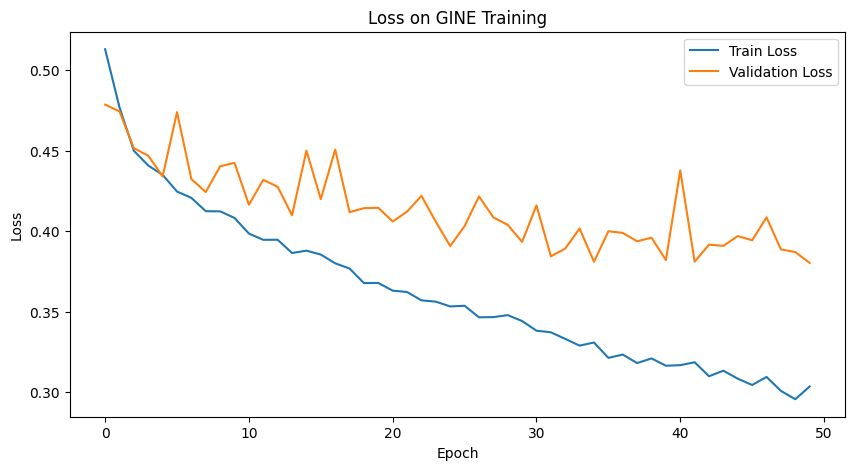

In [20]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss on GINE Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [21]:
# Evaluation
model.eval()
test_true, test_probs = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        probs = torch.sigmoid(out).cpu().numpy()
        test_probs.extend(probs)
        test_true.extend(batch.y.cpu().numpy())

test_preds = np.round(test_probs)
test_acc = accuracy_score(test_true, test_preds)
test_auc = roc_auc_score(test_true, test_probs)
cm = confusion_matrix(test_true, test_preds)

print('\n<== RESULTS ON TEST DATASET ==>')
print(f'Accuracy: {test_acc:.4f}')
print(f'AUC:      {test_auc:.4f}')
print('Confusion Matrix:')
print(cm)



<== RESULTS ON TEST DATASET ==>
Accuracy: 0.8574
AUC:      0.9261
Confusion Matrix:
[[854 110]
 [159 763]]


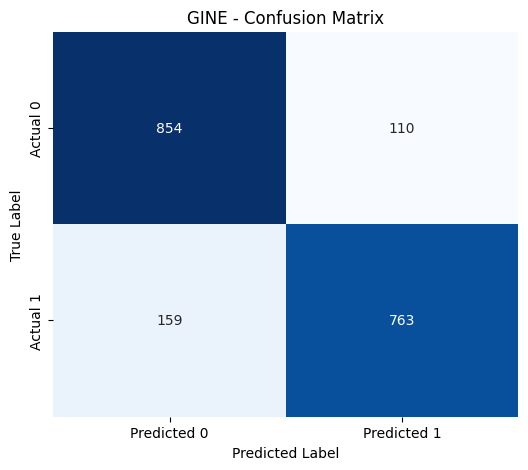

In [22]:
plot_confusion_matrix(cm, classes=['0', '1'], title='GINE - Confusion Matrix')
